In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
forecast_df = pd.read_csv("D:\\forecasting_project\\data\\final_sales_forecast.csv")
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

forecast_df

,date,forecast_quantity
0,2025-04-01,22212.566
1,2025-05-01,22060.280
2,2025-06-01,22060.280
3,2025-07-01,22213.738
4,2025-08-01,22060.280
5,2025-09-01,22060.280


In [57]:
purchase_df = pd.read_excel("D:\\forecasting_project\\data\\raw\\purchase_2021.xlsx")

In [58]:
purchase_df.head()
purchase_df.columns

Index(['Content.Company Name', 'Content.Voucher Number', 'Content.Reference',
       'Content.Date', 'Content.Voucher Type', 'Content.Party Name',
       'Content.Party Alias', 'Content.Party Address', 'Content.Party Pincode',
       'Content.Party Contact Person', 'Content.Party Telephone No.',
       'Content.Party Mobile No.', 'Content.Party Fax No.',
       'Content.Party E-Mail', 'Content.Party Group', 'Content.Party State',
       'Content.Party Notes', 'Content.Place of Receipt by Shipper',
       'Content.Vessel/Flight No.', 'Content.Port of Loading',
       'Content.Port of Discharge', 'Content.Destination Country',
       'Content.Order Number', 'Content.Order Due Date',
       'Content.Tracking Number', 'Content.Buyer's TIN No.',
       'Content.CST Number', 'Content.GSTIN/UIN', 'Content.Item Name',
       'Content.Item Alias', 'Content.Item Part No', 'Content.Item Group',
       'Content.Item Category', 'Content.Item Description',
       'Content.Item Notes', 'Content.Item 

In [59]:
purchase_df["financial_year"] = "2021-22"

In [60]:
month_map = {
    "January": 1, "February": 2, "March": 3,
    "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9,
    "October": 10, "November": 11, "December": 12
}

purchase_df["month_num"] = purchase_df["Content.Date"].map(month_map)

In [61]:
purchase_df[["Content.Date", "month_num"]].head()

,Content.Date,month_num
0,January,1.0
1,January,1.0
2,January,1.0
3,January,1.0
4,January,1.0


In [62]:
def extract_year(fin_year, month_num):
    start_year = int(fin_year.split("-")[0])
    end_year = start_year + 1
    return start_year if month_num >= 4 else end_year

purchase_df["year"] = purchase_df.apply(
    lambda row: extract_year(row["financial_year"], row["month_num"]),
    axis=1
)

In [63]:
purchase_df[["financial_year", "Content.Date", "year"]].head(10)

,financial_year,Content.Date,year
0,2021-22,January,2022
1,2021-22,January,2022
2,2021-22,January,2022
3,2021-22,January,2022
4,2021-22,January,2022
5,2021-22,January,2022
6,2021-22,January,2022
7,2021-22,January,2022
8,2021-22,January,2022
9,2021-22,January,2022


In [64]:
purchase_df[purchase_df["month_num"].isna()][["Content.Date"]].head()

,Content.Date
4516,NaN


In [65]:
purchase_df = purchase_df.dropna(subset=["month_num"])

In [66]:
purchase_df["month_num"] = purchase_df["month_num"].astype(int)

In [67]:
purchase_df["date"] = pd.to_datetime(
    purchase_df["year"].astype(str) + "-" +
    purchase_df["month_num"].astype(str) + "-01",
    format="%Y-%m-%d"
)

In [68]:
purchase_df[["Content.Date", "month_num", "year", "date"]].head(10)

,Content.Date,month_num,year,date
0,January,1,2022,2022-01-01
1,January,1,2022,2022-01-01
2,January,1,2022,2022-01-01
3,January,1,2022,2022-01-01
4,January,1,2022,2022-01-01
5,January,1,2022,2022-01-01
6,January,1,2022,2022-01-01
7,January,1,2022,2022-01-01
8,January,1,2022,2022-01-01
9,January,1,2022,2022-01-01


In [69]:
monthly_purchase = (
    purchase_df
    .groupby("date")["Content.Acutal Quantity"]
    .sum()
    .reset_index(name="purchase_quantity")
)


In [70]:
monthly_purchase = (
    purchase_df
    .groupby("date")["Content.Acutal Quantity"]
    .sum()
    .reset_index(name="purchase_quantity")
)

monthly_purchase.head()

,date,purchase_quantity
0,2021-04-01,3991.0
1,2021-05-01,7083.0
2,2021-06-01,13828.0
3,2021-07-01,13699.0
4,2021-08-01,10215.0


In [71]:
sales_df = pd.read_csv("../data/processed/monthly_sales.csv")
sales_df["date"] = pd.to_datetime(sales_df["date"])

sales_df.head()

,date,quantity
0,2021-04-01,3672.0
1,2021-05-01,9153.0
2,2021-06-01,11071.0
3,2021-07-01,10100.0
4,2021-08-01,15279.0


In [78]:
def process_purchase_file(file_path, financial_year):
    df = pd.read_excel(file_path)

    # Assign financial year manually
    df["financial_year"] = financial_year

    # Month mapping
    month_map = {
        "January": 1, "February": 2, "March": 3,
        "April": 4, "May": 5, "June": 6,
        "July": 7, "August": 8, "September": 9,
        "October": 10, "November": 11, "December": 12
    }

    df["month_num"] = df["Content.Date"].map(month_map)

    # Drop invalid months
    df = df.dropna(subset=["month_num"])
    df["month_num"] = df["month_num"].astype(int)

    # Convert FY → calendar year
    def extract_year(fin_year, month_num):
        start_year = int(fin_year.split("-")[0])
        return start_year if month_num >= 4 else start_year + 1

    df["year"] = df.apply(
        lambda row: extract_year(row["financial_year"], row["month_num"]),
        axis=1
    )

    # Create date
    df["date"] = pd.to_datetime(
        df["year"].astype(str) + "-" +
        df["month_num"].astype(str) + "-01",
        format="%Y-%m-%d"
    )

    # Monthly aggregation
    monthly = (
        df.groupby("date")["Content.Acutal Quantity"]
        .sum()
        .reset_index(name="purchase_quantity")
    )

    return monthly

In [80]:
purchase_2021 = process_purchase_file(r"D:\forecasting_project\data\raw\purchase_2021.xlsx", "2021-22")
purchase_2022 = process_purchase_file(r"D:\forecasting_project\data\raw\purchase_2022.xlsx", "2022-23")
purchase_2023 = process_purchase_file(r"D:\forecasting_project\data\raw\purchase_2023.xlsx", "2023-24")
purchase_2024 = process_purchase_file(r"D:\forecasting_project\data\raw\purchase_2024.xlsx", "2024-25")

In [81]:
all_purchase = pd.concat(
    [purchase_2021, purchase_2022, purchase_2023, purchase_2024],
    ignore_index=True
)

In [83]:
monthly_purchase = (
    all_purchase
    .groupby("date")["purchase_quantity"]
    .sum()
    .reset_index()
    .sort_values("date")
)

In [75]:
all_purchase = all_purchase.sort_values("date").reset_index(drop=True)

all_purchase.head()
all_purchase.tail()

,date,purchase_quantity
42,2024-11-01,12782.0
43,2024-12-01,154727.0
44,2025-01-01,9363.0
45,2025-02-01,17135.0
46,2025-03-01,85746.0


In [84]:
monthly_purchase.to_csv(
    "../data/processed/monthly_purchase.csv",
    index=False
)

In [85]:
all_purchase.to_csv(
    "../data/processed/full_monthly_purchase_2021-2024.csv",
    index=False
)

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

monthly_purchase = pd.read_csv(
    "../data/processed/monthly_purchase.csv"
)
monthly_sales = pd.read_csv(
    "../data/processed/monthly_sales.csv"
)

monthly_purchase["date"] = pd.to_datetime(monthly_purchase["date"])
monthly_sales["date"] = pd.to_datetime(monthly_sales["date"])

In [87]:
monthly_purchase.head()
monthly_sales.head()

,date,quantity
0,2021-04-01,3672.0
1,2021-05-01,9153.0
2,2021-06-01,11071.0
3,2021-07-01,10100.0
4,2021-08-01,15279.0


In [88]:
inventory_df = monthly_sales.merge(
    monthly_purchase,
    on="date",
    how="left"
)

inventory_df["purchase_quantity"] = inventory_df["purchase_quantity"].fillna(0)

inventory_df.head()

,date,quantity,purchase_quantity
0,2021-04-01,3672.0,3991.0
1,2021-05-01,9153.0,7083.0
2,2021-06-01,11071.0,13828.0
3,2021-07-01,10100.0,13699.0
4,2021-08-01,15279.0,10215.0


In [89]:
inventory_df = inventory_df.sort_values("date").reset_index(drop=True)

inventory_df["stock_balance"] = (
    inventory_df["purchase_quantity"].cumsum()
    - inventory_df["quantity"].cumsum()
)

inventory_df.tail()

,date,quantity,purchase_quantity,stock_balance
30,2024-11-01,118500.0,12782.0,43569.0
31,2024-12-01,22529.0,154727.0,175767.0
32,2025-01-01,12834.0,9363.0,172296.0
33,2025-02-01,21788.0,17135.0,167643.0
34,2025-03-01,16204.0,85746.0,237185.0


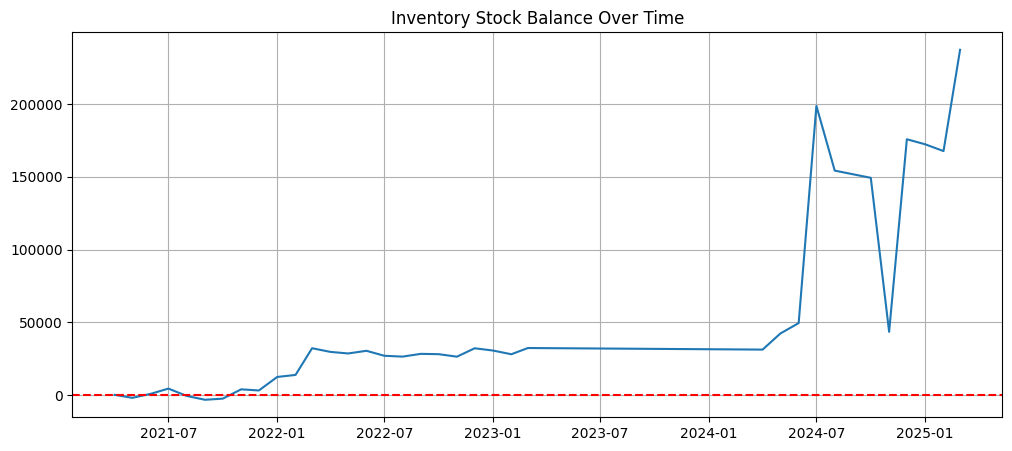

In [90]:
plt.figure(figsize=(12,5))
plt.plot(inventory_df["date"], inventory_df["stock_balance"])
plt.axhline(0, color="red", linestyle="--")
plt.title("Inventory Stock Balance Over Time")
plt.grid(True)
plt.show()

In [91]:
forecast_df = pd.read_csv(
    "../data/final_sales_forecast.csv"
)
forecast_df["date"] = pd.to_datetime(forecast_df["date"])

forecast_df

,date,forecast_quantity
0,2025-04-01,22212.566
1,2025-05-01,22060.280
2,2025-06-01,22060.280
3,2025-07-01,22213.738
4,2025-08-01,22060.280
5,2025-09-01,22060.280


In [92]:
future_inventory = forecast_df.copy()
future_inventory["purchase_quantity"] = 0
future_inventory["stock_balance"] = np.nan

inventory_df = pd.concat(
    [inventory_df, future_inventory],
    ignore_index=True
)

In [93]:
avg_demand = monthly_sales["quantity"].mean()
safety_stock = 1.5 * avg_demand

In [94]:
current_stock = inventory_df.loc[
    inventory_df["stock_balance"].notna(),
    "stock_balance"
].iloc[-1]

In [95]:
forecast_demand = forecast_df["forecast_quantity"].sum()

In [96]:
restock_alert = forecast_demand > (current_stock - safety_stock)
overstock_alert = current_stock > (3 * avg_demand)

restock_alert, overstock_alert

(np.False_, np.True_)

In [97]:
decision_summary = pd.DataFrame({
    "Metric": [
        "Current Stock",
        "Average Monthly Demand",
        "6-Month Forecast Demand",
        "Safety Stock",
        "Restock Alert",
        "Overstock Alert"
    ],
    "Value": [
        current_stock,
        avg_demand,
        forecast_demand,
        safety_stock,
        restock_alert,
        overstock_alert
    ]
})

decision_summary

,Metric,Value
0,Current Stock,237185.0
1,Average Monthly Demand,16494.6
2,6-Month Forecast Demand,132667.424
3,Safety Stock,24741.9
4,Restock Alert,False
5,Overstock Alert,True


In [99]:
forecast_df.to_csv("../data/outputs/forecast.csv", index=False)
inventory_df.to_csv("../data/outputs/inventory_status.csv", index=False)
decision_summary.to_csv("../data/outputs/decision_summary.csv", index=False)